In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 16573292.26it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 500688.99it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 4513829.79it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 3977976.36it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [2]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1 = nn.Linear(64*12*12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(-1, 64*12*12)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)


In [6]:
import torch.optim as optim

model = SimpleCNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, optimizer, criterion, num_epochs):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

        print(f'Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}, Accuracy: {correct/len(train_loader.dataset)}')

train_model(model, train_loader, optimizer, criterion, 10)


Epoch 1, Loss: 0.14291050787523651, Accuracy: 0.9571166666666666
Epoch 2, Loss: 0.042665832586013586, Accuracy: 0.9868
Epoch 3, Loss: 0.027352260799816886, Accuracy: 0.9914666666666667
Epoch 4, Loss: 0.018402388315748728, Accuracy: 0.99395
Epoch 5, Loss: 0.01390619663868644, Accuracy: 0.9953833333333333
Epoch 6, Loss: 0.01075356513541171, Accuracy: 0.9963166666666666
Epoch 7, Loss: 0.008289557836077977, Accuracy: 0.9971333333333333
Epoch 8, Loss: 0.00731843894207463, Accuracy: 0.9973166666666666
Epoch 9, Loss: 0.006685462200912499, Accuracy: 0.9977833333333334
Epoch 10, Loss: 0.004987452759662734, Accuracy: 0.9982333333333333


In [9]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def evaluate_model(model, test_loader):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()  # Sum up batch loss
            pred = output.argmax(dim=1)  # Get the index of the max log-probability
            correct += pred.eq(target).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = correct / len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.4%})\n')
    return accuracy

test_accuracy = evaluate_model(model, test_loader)



Test set: Average loss: 0.0009, Accuracy: 9886/10000 (98.8600%)



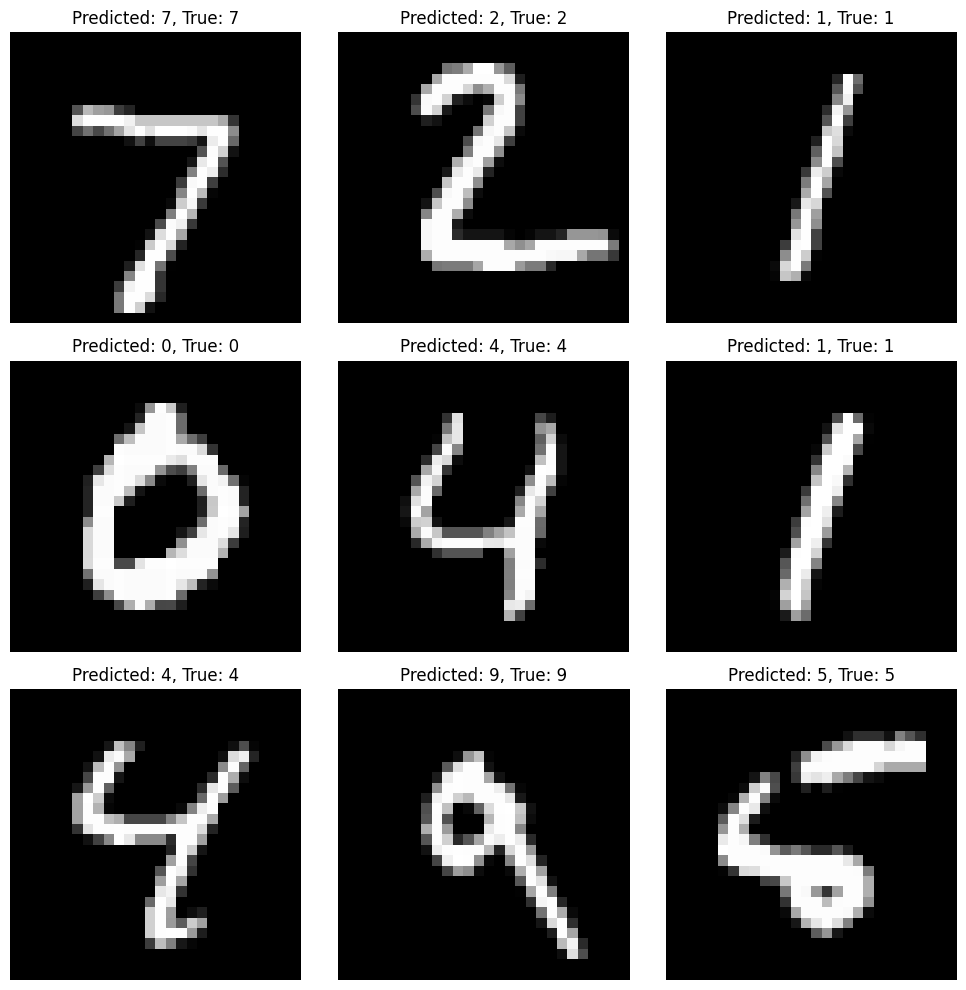

In [12]:
import matplotlib.pyplot as plt

# Function to visualize the predictions
def visualize_predictions(model, test_loader):
    model.eval()  # Set the model to evaluation mode
    data_iter = iter(test_loader)
    images, labels = next(data_iter)  # Get a batch of test data

    # Make predictions
    output = model(images)
    _, preds = torch.max(output, 1)  # Get predicted classes

    # Plot images along with their predicted and true labels
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Show 9 images
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')  # Show image
        plt.title(f'Predicted: {preds[i].item()}, True: {labels[i].item()}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Call the function to visualize predictions
visualize_predictions(model, test_loader)


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define the MLP model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create an instance of the model
mlp_model = MLP()

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# Training function
def train_model(model, train_loader, epochs=10):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}')

# Load dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# Train the MLP model
train_model(mlp_model, train_loader)

# Evaluate the MLP model
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

# Load test dataset
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Evaluate the MLP model
evaluate_model(mlp_model, test_loader)




Epoch 1, Loss: 0.3812
Epoch 2, Loss: 0.1879
Epoch 3, Loss: 0.1388
Epoch 4, Loss: 0.1132
Epoch 5, Loss: 0.0962
Epoch 6, Loss: 0.0839
Epoch 7, Loss: 0.0751
Epoch 8, Loss: 0.0647
Epoch 9, Loss: 0.0602
Epoch 10, Loss: 0.0544
Accuracy: 97.31%


In [15]:
class CNNWithDropout(nn.Module):
    def __init__(self, dropout_prob=0.5):
        super(CNNWithDropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=dropout_prob)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv3(x))
        x = torch.max_pool2d(x, 2)
        x = x.view(-1, 128*3*3)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Create an instance of the model with dropout
cnn_model = CNNWithDropout(dropout_prob=0.5)

# Define the loss function and optimizer with a different learning rate
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)  # Adjust learning rate here


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

class MLPWithDropout(nn.Module):
    def __init__(self, dropout_prob=0.5):
        super(MLPWithDropout, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.dropout1 = nn.Dropout(p=dropout_prob)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(p=dropout_prob)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Create an instance of the model with dropout
mlp_model = MLPWithDropout(dropout_prob=0.5)

# Define the loss function and optimizer with a different learning rate
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)  # Adjust learning rate here


Training MLP Model
Epoch 1, Loss: 0.7722
Epoch 2, Loss: 0.4926
Epoch 3, Loss: 0.4419
Epoch 4, Loss: 0.4157
Epoch 5, Loss: 0.3932
Epoch 6, Loss: 0.3729
Epoch 7, Loss: 0.3677
Epoch 8, Loss: 0.3587
Epoch 9, Loss: 0.3527
Epoch 10, Loss: 0.3441
Evaluating MLP Model
Accuracy: 95.17%
Training CNN Model
Epoch 1, Loss: 0.2504
Epoch 2, Loss: 0.0762
Epoch 3, Loss: 0.0541
Epoch 4, Loss: 0.0432
Epoch 5, Loss: 0.0346
Epoch 6, Loss: 0.0311
Epoch 7, Loss: 0.0264
Epoch 8, Loss: 0.0228
Epoch 9, Loss: 0.0212
Epoch 10, Loss: 0.0186
Evaluating CNN Model
Accuracy: 99.35%
Visualizing MLP Model Predictions


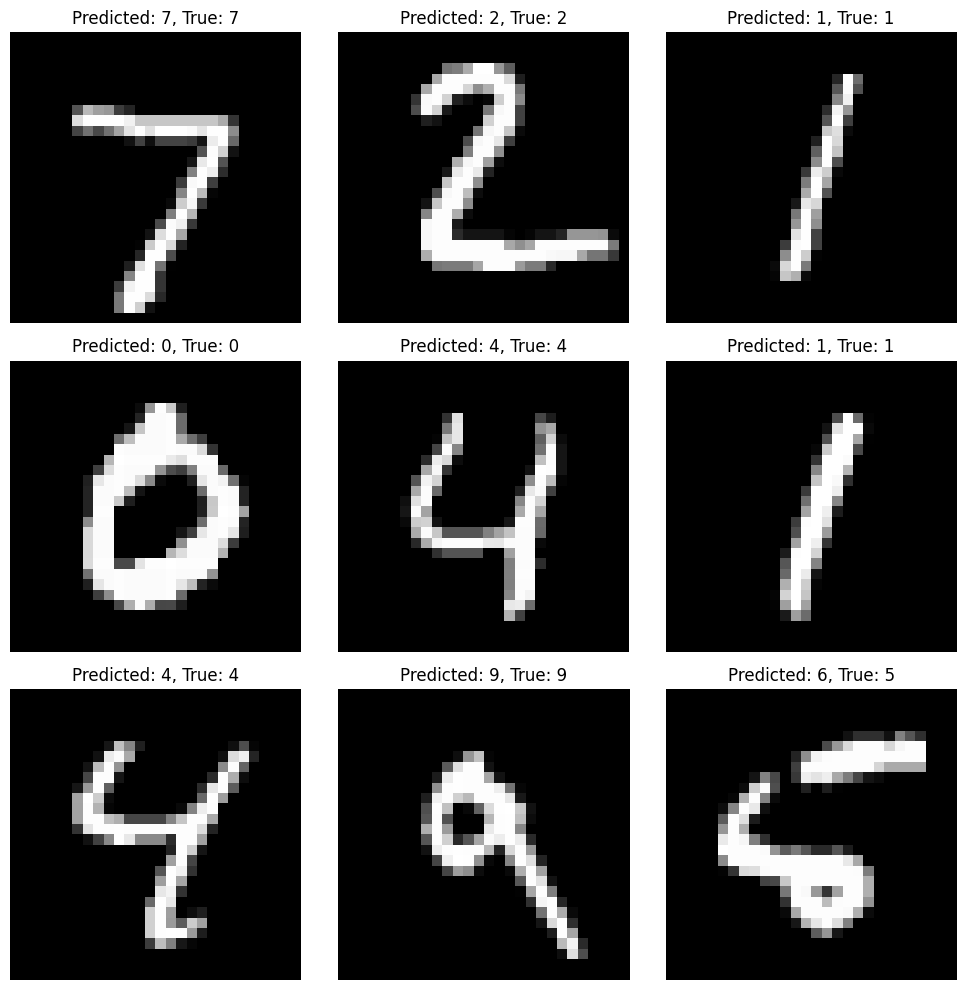

Visualizing CNN Model Predictions


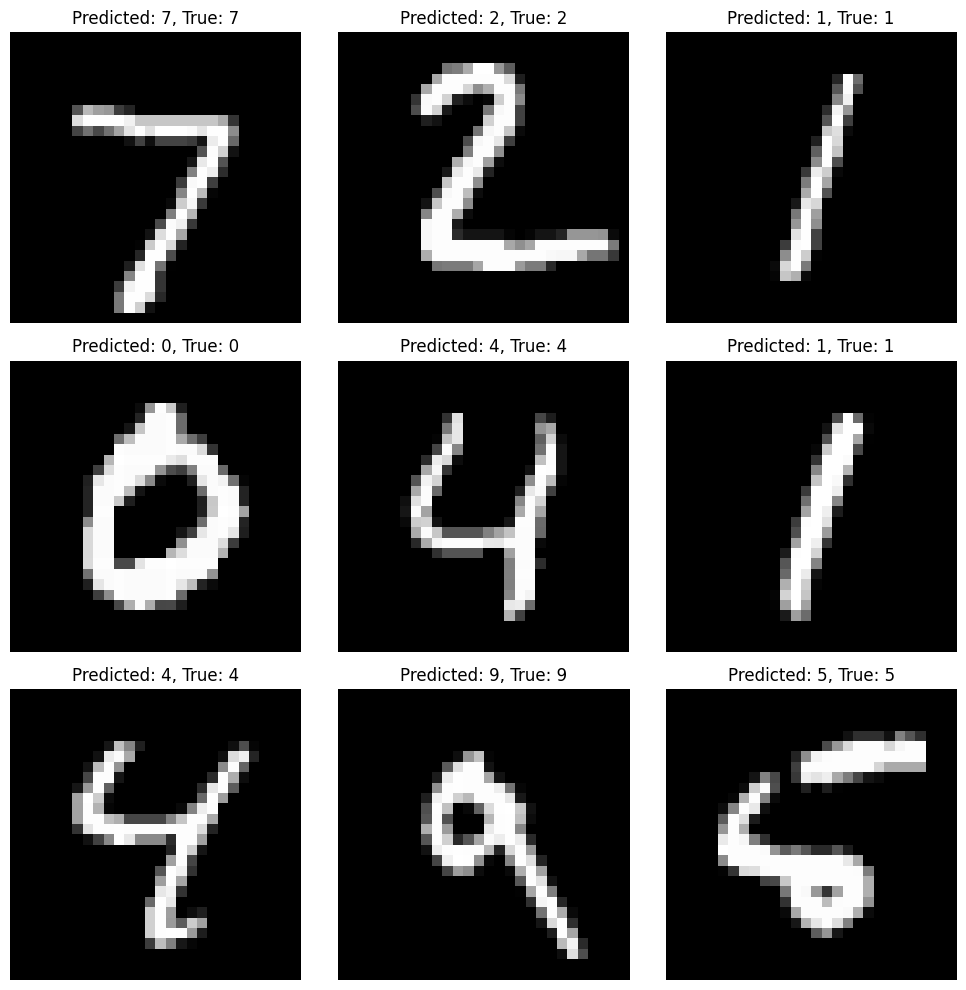

In [18]:
# Function to train the model
def train_model(model, train_loader, optimizer, criterion, epochs=10):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}')

# Function to evaluate the model
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

# Create instances of the updated models
mlp_model = MLPWithDropout(dropout_prob=0.5)
cnn_model = CNNWithDropout(dropout_prob=0.5)

# Define the loss function and optimizers
criterion = nn.CrossEntropyLoss()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)  # Adjust learning rate if needed
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)  # Adjust learning rate if needed

# Load datasets
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Train and evaluate MLP model
print("Training MLP Model")
train_model(mlp_model, train_loader, mlp_optimizer, criterion)
print("Evaluating MLP Model")
evaluate_model(mlp_model, test_loader)

# Train and evaluate CNN model
print("Training CNN Model")
train_model(cnn_model, train_loader, cnn_optimizer, criterion)
print("Evaluating CNN Model")
evaluate_model(cnn_model, test_loader)

# Visualize predictions for both models
print("Visualizing MLP Model Predictions")
visualize_predictions(mlp_model, test_loader)

print("Visualizing CNN Model Predictions")
visualize_predictions(cnn_model, test_loader)


Visualizing MLP Model Predictions


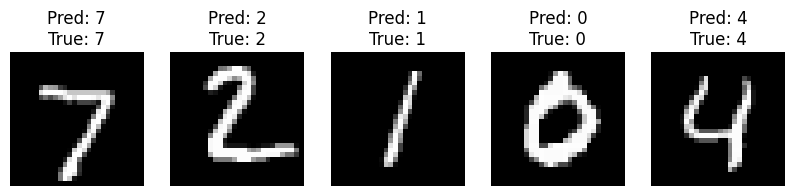

Visualizing CNN Model Predictions


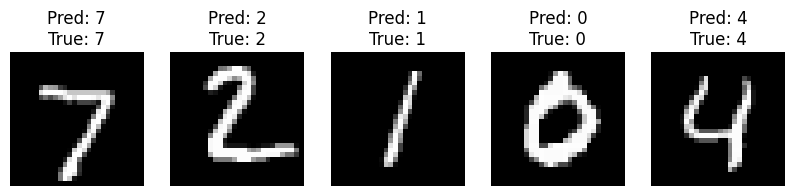

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, data_loader, num_images=5):
    model.eval()  # Set the model to evaluation mode
    data_iter = iter(data_loader)

    # Plot a few test images and their predicted labels
    images, labels = next(data_iter)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    # Convert tensor to numpy arrays for plotting
    images = images.numpy()
    preds = preds.numpy()
    labels = labels.numpy()

    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(np.squeeze(images[i]), cmap='gray')
        plt.title(f"Pred: {preds[i]}\nTrue: {labels[i]}")
        plt.axis('off')
    plt.show()

# Visualize predictions for both models
print("Visualizing MLP Model Predictions")
visualize_predictions(mlp_model, test_loader)

print("Visualizing CNN Model Predictions")
visualize_predictions(cnn_model, test_loader)


In [16]:
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

Visualizing CNN Model Predictions with Colorful Labels


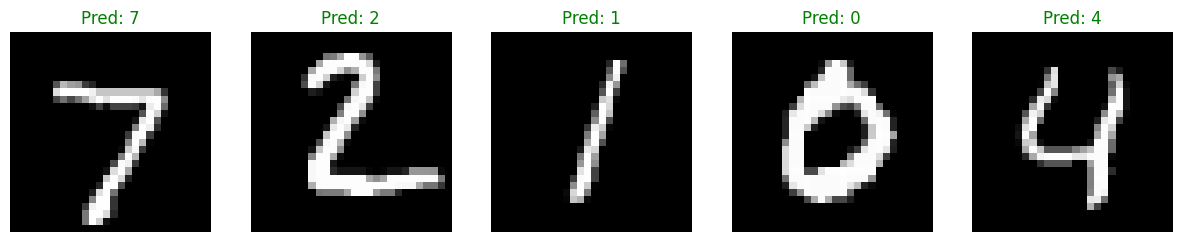

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_cnn_predictions(model, data_loader, num_images=5):
    model.eval()  # Set the model to evaluation mode
    data_iter = iter(data_loader)

    # Get a batch of test data
    images, labels = next(data_iter)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    # Convert images to numpy for plotting
    images = images.numpy()
    preds = preds.numpy()
    labels = labels.numpy()

    # Plot the images with colorful titles for predictions and true labels
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(np.squeeze(images[i]), cmap='gray')  # Grayscale images
        plt.title(f"Pred: {preds[i]}", color='green' if preds[i] == labels[i] else 'red')  # Green for correct, red for wrong
        plt.xlabel(f"True: {labels[i]}")
        plt.axis('off')
    plt.show()

# Call the function for the CNN model
print("Visualizing CNN Model Predictions with Colorful Labels")
visualize_cnn_predictions(cnn_model, test_loader)


In [21]:
from sklearn.metrics import classification_report

def calculate_metrics(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    # Collect all predictions and labels
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate classification report with precision, recall, and f1-score
    print("Classification Report for CNN Model:")
    print(classification_report(all_labels, all_preds, digits=4))

# Calculate precision, recall, and f1-score for the CNN model
calculate_metrics(cnn_model, test_loader)


Classification Report for CNN Model:
              precision    recall  f1-score   support

           0     0.9949    0.9959    0.9954       980
           1     0.9956    0.9991    0.9974      1135
           2     0.9942    0.9952    0.9947      1032
           3     0.9902    0.9990    0.9946      1010
           4     0.9929    0.9959    0.9944       982
           5     0.9932    0.9877    0.9904       892
           6     0.9989    0.9812    0.9900       958
           7     0.9884    0.9942    0.9913      1028
           8     0.9928    0.9979    0.9954       974
           9     0.9940    0.9871    0.9906      1009

    accuracy                         0.9935     10000
   macro avg     0.9935    0.9933    0.9934     10000
weighted avg     0.9935    0.9935    0.9935     10000



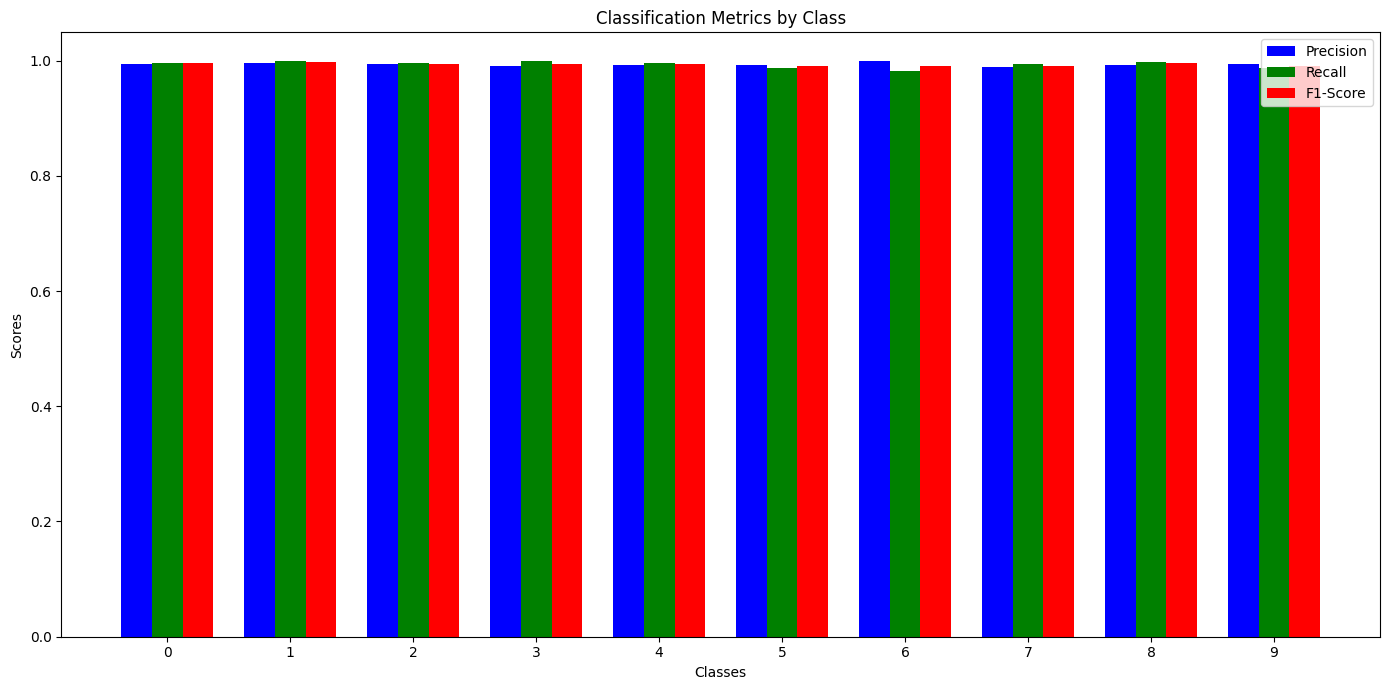

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def collect_predictions_and_labels(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

# Collect predictions and labels for CNN model
all_labels, all_preds = collect_predictions_and_labels(cnn_model, test_loader)
import matplotlib.pyplot as plt
import numpy as np

def plot_classification_report(report):
    # Extract data from the report
    classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
    precision = [report[c]['precision'] for c in classes]
    recall = [report[c]['recall'] for c in classes]
    f1_score = [report[c]['f1-score'] for c in classes]

    x = np.arange(len(classes))  # The label locations
    width = 0.25  # The width of the bars

    fig, ax = plt.subplots(figsize=(14, 7))
    bars1 = ax.bar(x - width, precision, width, label='Precision', color='b')
    bars2 = ax.bar(x, recall, width, label='Recall', color='g')
    bars3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='r')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_xlabel('Classes')
    ax.set_ylabel('Scores')
    ax.set_title('Classification Metrics by Class')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()

    fig.tight_layout()

    plt.show()

# Convert classification report dictionary to the format needed
report_dict = classification_report(all_labels, all_preds, output_dict=True)
plot_classification_report(report_dict)


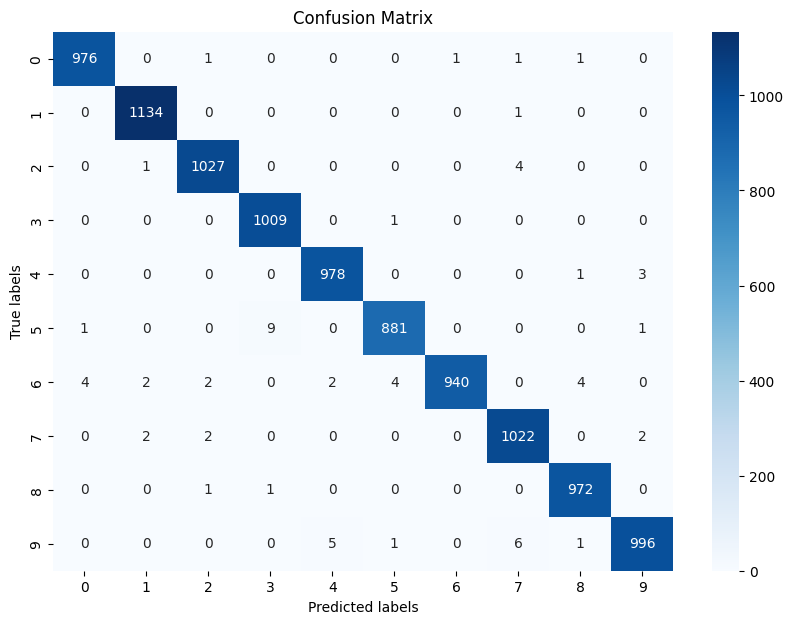

In [28]:
def plot_confusion_matrix(labels, preds, num_classes=10):
    cm = confusion_matrix(labels, preds, labels=range(num_classes))
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(all_labels, all_preds)


In [22]:
def find_misclassified(model, data_loader, num_images=5):
    model.eval()
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    # Find indices where predictions are incorrect
    misclassified_indices = np.where(preds != labels)[0]

    # Plot misclassified images
    plt.figure(figsize=(10, 10))
    for i, index in enumerate(misclassified_indices[:num_images]):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(np.squeeze(images[index]), cmap='gray')
        plt.title(f"Pred: {preds[index]}, True: {labels[index]}", color='red')
        plt.axis('off')
    plt.show()

# Visualize misclassified examples from the CNN model
find_misclassified(cnn_model, test_loader)


<Figure size 1000x1000 with 0 Axes>

In [23]:
from sklearn.metrics import accuracy_score

def class_wise_accuracy(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute accuracy for each class
    for i in range(10):
        class_preds = [1 if label == i and pred == i else 0 for label, pred in zip(all_labels, all_preds)]
        class_true = [1 if label == i else 0 for label in all_labels]
        accuracy = accuracy_score(class_true, class_preds)
        print(f"Accuracy for class {i}: {accuracy:.4f}")

# Calculate class-wise accuracy for the CNN model
class_wise_accuracy(cnn_model, test_loader)


Accuracy for class 0: 0.9996
Accuracy for class 1: 0.9999
Accuracy for class 2: 0.9995
Accuracy for class 3: 0.9999
Accuracy for class 4: 0.9996
Accuracy for class 5: 0.9989
Accuracy for class 6: 0.9982
Accuracy for class 7: 0.9994
Accuracy for class 8: 0.9998
Accuracy for class 9: 0.9987


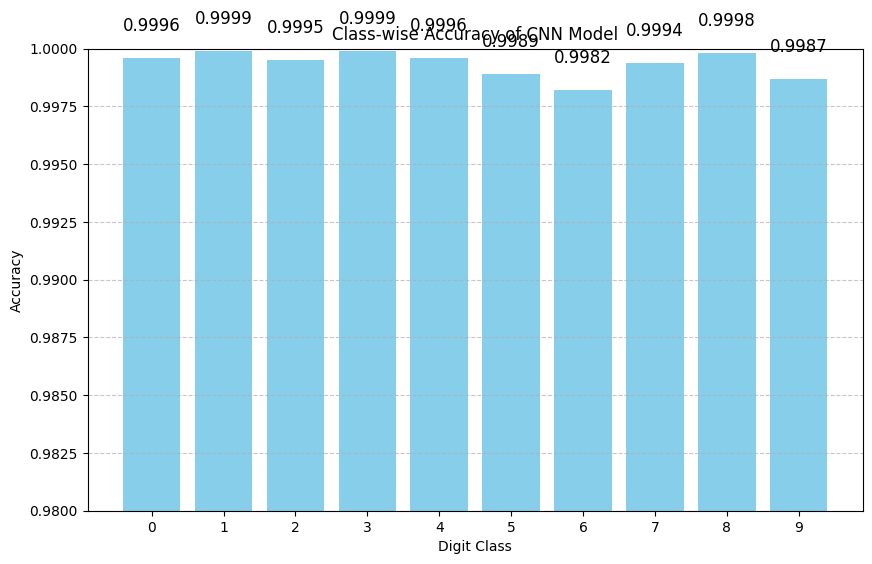

In [29]:
import matplotlib.pyplot as plt

# Define class names for MNIST
class_names = [str(i) for i in range(10)]

# Define accuracies for each class
accuracies = [0.9996, 0.9999, 0.9995, 0.9999, 0.9996, 0.9989, 0.9982, 0.9994, 0.9998, 0.9987]

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(class_names, accuracies, color='skyblue')
plt.xlabel('Digit Class')
plt.ylabel('Accuracy')
plt.title('Class-wise Accuracy of CNN Model')
plt.ylim(0.98, 1.0)  # Set the y-axis limits for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.001, f'{acc:.4f}', ha='center', va='bottom', fontsize=12)

plt.show()


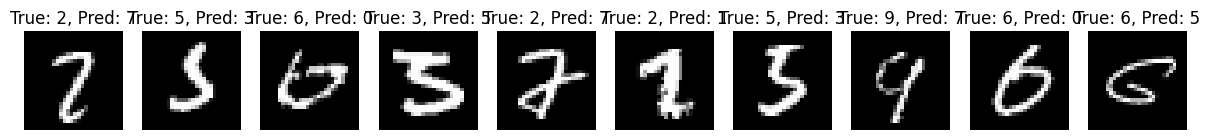

In [30]:
import matplotlib.pyplot as plt

def visualize_misclassified_examples(model, data_loader, num_examples=10):
    model.eval()
    misclassified_images = []
    misclassified_labels = []
    misclassified_preds = []

    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:  # Misclassified
                    misclassified_images.append(images[i].cpu())
                    misclassified_labels.append(labels[i].cpu())
                    misclassified_preds.append(preds[i].cpu())

                if len(misclassified_images) >= num_examples:
                    break
            if len(misclassified_images) >= num_examples:
                break

    # Plotting misclassified examples
    fig, axes = plt.subplots(1, num_examples, figsize=(15, 3))
    for i in range(num_examples):
        axes[i].imshow(misclassified_images[i].numpy().squeeze(), cmap='gray')
        axes[i].set_title(f"True: {misclassified_labels[i]}, Pred: {misclassified_preds[i]}")
        axes[i].axis('off')
    plt.show()

# Call the function to visualize misclassified examples
visualize_misclassified_examples(cnn_model, test_loader, num_examples=10)


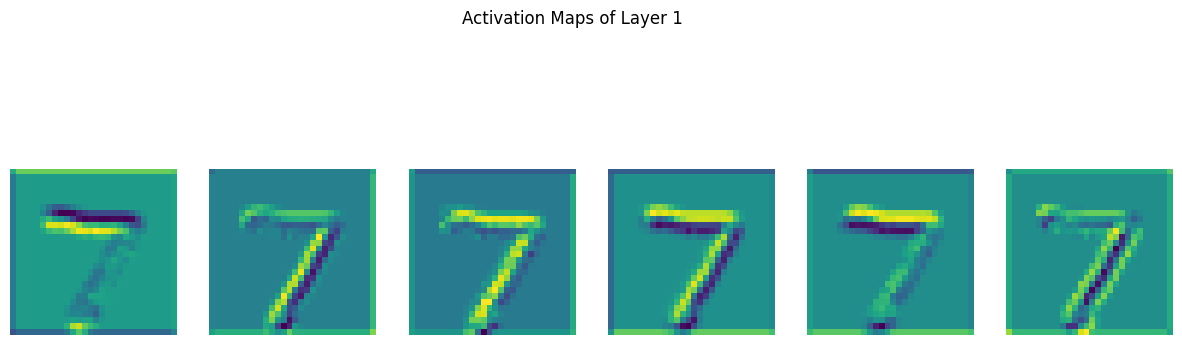

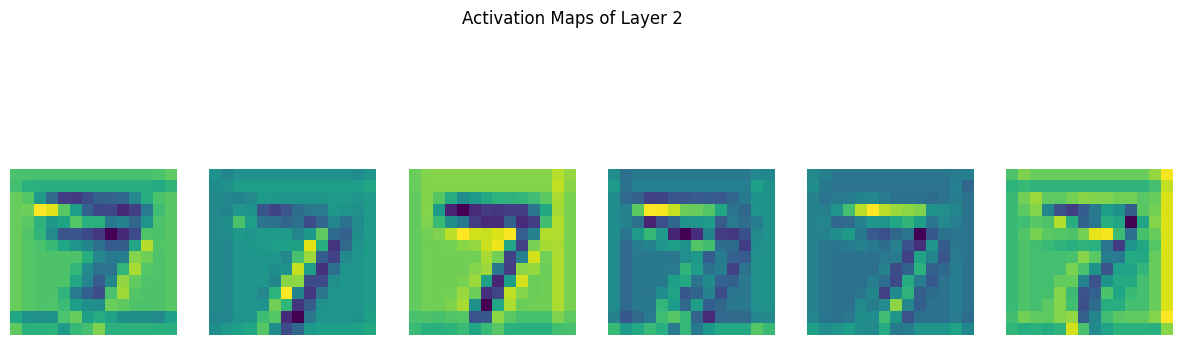

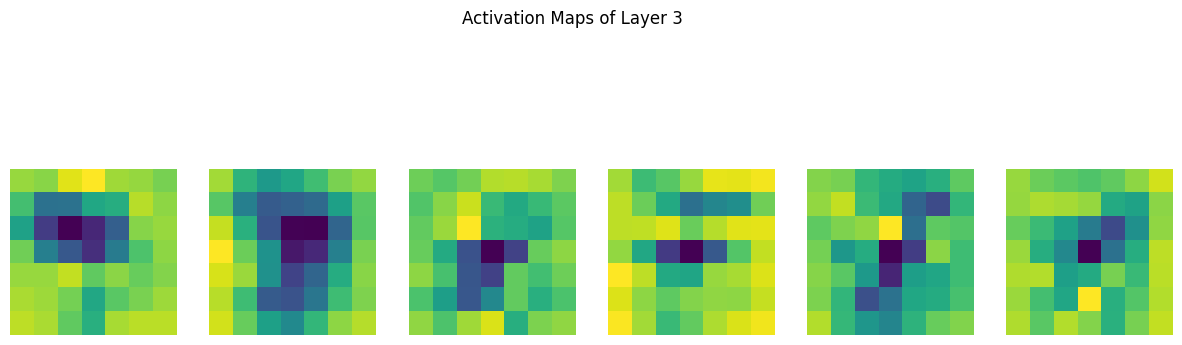

In [32]:
import torch
import matplotlib.pyplot as plt

def visualize_activation_maps(model, image):
    model.eval()
    activation_maps = []
    hooks = []

    # Hook function to capture activations
    def hook_fn(module, input, output):
        activation_maps.append(output)

    # Register hooks to each convolutional layer in the model
    for layer in model.children():
        if isinstance(layer, torch.nn.Conv2d):
            hooks.append(layer.register_forward_hook(hook_fn))

    # Pass the image through the model to capture activations
    with torch.no_grad():
        model(image.unsqueeze(0))  # Add batch dimension

    # Remove hooks after getting activations
    for hook in hooks:
        hook.remove()

    # Plot the activation maps for each convolutional layer
    for idx, activation in enumerate(activation_maps):
        activation = activation.squeeze(0)  # Remove batch dimension
        num_filters = activation.size(0)

        fig, axes = plt.subplots(1, min(num_filters, 6), figsize=(15, 5))  # Show first 6 filters
        fig.suptitle(f'Activation Maps of Layer {idx + 1}')
        for i in range(min(num_filters, 6)):  # Limit to 6 filters for visualization
            axes[i].imshow(activation[i].cpu().numpy(), cmap='viridis')
            axes[i].axis('off')
        plt.show()

# Select an image from the test set
image, label = next(iter(test_loader))
image = image[0]  # Select the first image

# Visualize activation maps
visualize_activation_maps(cnn_model, image)
